In [1]:
import pandas as pd

In [2]:
df_survey_results = pd.read_csv('dataset/survey_results.csv')
df_survey_results.head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250
3,R00004,33,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
4,R00005,23,M,Metro,Student,NaN,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100


### Step1: Remove Duplicates

In [3]:
remove_dup_df = df_survey_results.drop_duplicates()

### Step2: Outlier Detection in Age

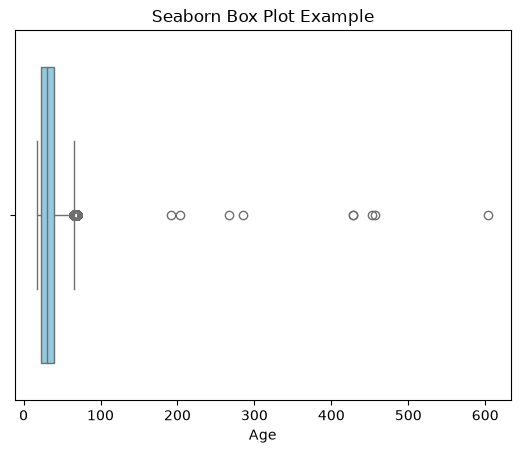

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the box plot
sns.boxplot(x=remove_dup_df.age, color="skyblue")

# Add title and labels
plt.title("Seaborn Box Plot Example")
plt.xlabel("Age")

# Display the plot
plt.show()

In [5]:
remove_dup_df.age.describe()

count    30000.000000
mean        33.048167
std         13.438904
min         18.000000
25%         23.000000
50%         31.000000
75%         40.000000
max        604.000000
Name: age, dtype: float64

In [6]:
# Keep only valid age values between 1 and 100
remove_dup_df = remove_dup_df[
    remove_dup_df['age'].between(1, 100)
].copy()

In [7]:
remove_dup_df['age'].describe()

count    29991.000000
mean        32.947484
std         11.906077
min         18.000000
25%         23.000000
50%         31.000000
75%         40.000000
max         70.000000
Name: age, dtype: float64

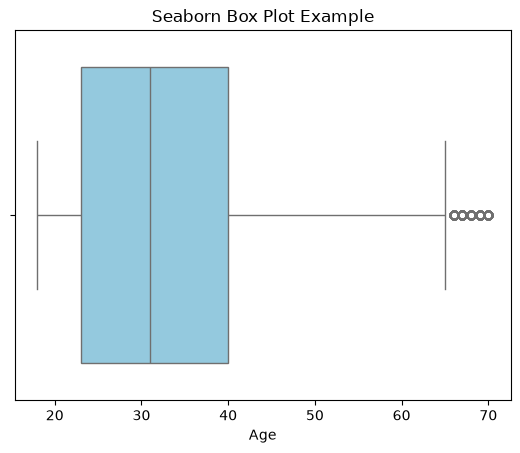

In [8]:
# Create the box plot
sns.boxplot(x=remove_dup_df.age, color="skyblue")

# Add title and labels
plt.title("Seaborn Box Plot Example")
plt.xlabel("Age")

# Display the plot
plt.show()

### Step3: Handling Missing Data

In [9]:
remove_dup_df = remove_dup_df.copy()

remove_dup_df['income_levels'] = (
    remove_dup_df['income_levels'].fillna('Not Reported')
)

remove_dup_df[remove_dup_df.income_levels.isnull()]

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range


In [10]:
remove_dup_df[remove_dup_df.income_levels=="Not Reported"]

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
4,R00005,23,M,Metro,Student,Not Reported,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100
5,R00006,22,F,Urban,Student,Not Reported,5-7 times,Established,Large (1 L),2 to 4,Price,Traditional,Online,Simple,Low (Not very concerned),"Active (eg. Sports, gym)",100-150
11,R00012,23,F,Urban,Student,Not Reported,0-2 times,Established,Small (250 ml),0 to 1,Price,Exotic,Retail Store,Premium,Low (Not very concerned),Social (eg. Parties),50-100
14,R00015,22,M,Metro,Student,Not Reported,3-4 times,Established,Small (250 ml),0 to 1,Price,Traditional,Retail Store,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
20,R00021,23,M,Semi-Urban,Student,Not Reported,3-4 times,Newcomer,Large (1 L),0 to 1,Availability,Traditional,Retail Store,Premium,Low (Not very concerned),"Active (eg. Sports, gym)",50-100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,R29986,24,F,Metro,Student,Not Reported,5-7 times,Newcomer,Small (250 ml),0 to 1,Price,Traditional,Online,Premium,Low (Not very concerned),Social (eg. Parties),100-150
29996,R29987,22,M,Urban,Student,Not Reported,0-2 times,Established,Small (250 ml),0 to 1,Price,Exotic,Online,Premium,Low (Not very concerned),Social (eg. Parties),50-100
29999,R29990,23,F,Metro,Student,Not Reported,3-4 times,Established,Small (250 ml),2 to 4,Price,Exotic,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
30002,R29993,18,M,Metro,Student,Not Reported,0-2 times,Established,Medium (500 ml),2 to 4,Availability,Exotic,Online,Premium,Low (Not very concerned),Social (eg. Parties),100-150


In [11]:
print(remove_dup_df['consume_frequency(weekly)'].mode())

0    3-4 times
Name: consume_frequency(weekly), dtype: str


### Step4:Correct Spelling Mistakes in Categorical Data

In [12]:
remove_dup_df.zone.value_counts()

zone
Metro         11906
Urban         10686
Semi-Urban     5274
Rural          2116
urbna             5
Metor             4
Name: count, dtype: int64

In [13]:
remove_dup_df.current_brand.value_counts()

current_brand
Established    15442
Newcomer       14499
newcomer          30
Establishd        20
Name: count, dtype: int64

# Feature Engineering

### Step 1: Categorize Age into Age Groups

In [14]:
def age_group(age):
    if age <= 25:
        return '18-25'
    elif age <= 35:
        return '26-35'
    elif age <= 45:
        return '36-45'
    elif age <= 55:
        return '46-55'
    elif age <= 70:
        return '56-70'
    else:
        return '70+'

df_feature = remove_dup_df.copy()

df_feature['age_group'] = remove_dup_df['age'].apply(age_group)

In [15]:
df_feature.head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,46-55
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250,36-45
3,R00004,33,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200,26-35
4,R00005,23,M,Metro,Student,Not Reported,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100,18-25


In [16]:
remove_dup_df['consume_frequency(weekly)'].value_counts(dropna=False)

consume_frequency(weekly)
3-4 times    11786
5-7 times     9774
0-2 times     8423
NaN              8
Name: count, dtype: int64

In [17]:
remove_dup_df['consume_frequency(weekly)'] = (
    remove_dup_df['consume_frequency(weekly)']
    .fillna(remove_dup_df['consume_frequency(weekly)'].mode()[0])
)

In [18]:
remove_dup_df['consume_frequency(weekly)'].value_counts(dropna=False)

consume_frequency(weekly)
3-4 times    11794
5-7 times     9774
0-2 times     8423
Name: count, dtype: int64

In [19]:
def consume_frequency_group(consume_frequency):
    if consume_frequency == "0-2 times":
        return 1
    elif consume_frequency == "3-4 times":
        return 2
    elif consume_frequency == "5-7 times":
        return 3

df_feature = df_feature.copy()

df_feature['consume_frequency(weekly)'] = remove_dup_df['consume_frequency(weekly)'].apply(consume_frequency_group)
df_feature.head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group
0,R00001,30,M,Urban,Working Professional,<10L,2,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35
1,R00002,46,F,Metro,Working Professional,> 35L,3,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,46-55
2,R00003,41,F,Rural,Working Professional,> 35L,2,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250,36-45
3,R00004,33,F,Urban,Working Professional,16L - 25L,3,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200,26-35
4,R00005,23,M,Metro,Student,Not Reported,2,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100,18-25


In [20]:
def awareness_group(awareness):
    if awareness == "0 to 1":
        return 1
    elif awareness == "2 to 4":
        return 2
    elif awareness == "above 4":
        return 3

df_feature = df_feature.copy()

df_feature['awareness_of_other_brands'] = remove_dup_df['awareness_of_other_brands'].apply(awareness_group)
df_feature.head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group
0,R00001,30,M,Urban,Working Professional,<10L,2,Newcomer,Medium (500 ml),1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35
1,R00002,46,F,Metro,Working Professional,> 35L,3,Established,Medium (500 ml),2,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,46-55
2,R00003,41,F,Rural,Working Professional,> 35L,2,Newcomer,Medium (500 ml),2,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250,36-45
3,R00004,33,F,Urban,Working Professional,16L - 25L,3,Newcomer,Medium (500 ml),1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200,26-35
4,R00005,23,M,Metro,Student,Not Reported,2,Established,Medium (500 ml),1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100,18-25


In [21]:
df_feature['cf_ab_score'] = df_feature.apply(
    lambda x: x['consume_frequency(weekly)'] / (x['awareness_of_other_brands'] + x['consume_frequency(weekly)'])
    if (x['awareness_of_other_brands'] + x['consume_frequency(weekly)']) != 0 else 0,
    axis=1
).round(2)

df_feature.head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group,cf_ab_score
0,R00001,30,M,Urban,Working Professional,<10L,2,Newcomer,Medium (500 ml),1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35,0.67
1,R00002,46,F,Metro,Working Professional,> 35L,3,Established,Medium (500 ml),2,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,46-55,0.60
2,R00003,41,F,Rural,Working Professional,> 35L,2,Newcomer,Medium (500 ml),2,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250,36-45,0.50
3,R00004,33,F,Urban,Working Professional,16L - 25L,3,Newcomer,Medium (500 ml),1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200,26-35,0.75
4,R00005,23,M,Metro,Student,Not Reported,2,Established,Medium (500 ml),1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100,18-25,0.67


In [22]:
print(f"Max. value is: {df_feature.cf_ab_score.max()} and Min. value is: {df_feature.cf_ab_score.min()}")

Max. value is: 0.75 and Min. value is: 0.25


### Step 3: Create Zone Affluence Score (ZAS)

In [23]:
df_feature.zone.value_counts()

zone
Metro         11906
Urban         10686
Semi-Urban     5274
Rural          2116
urbna             5
Metor             4
Name: count, dtype: int64

In [24]:
remove_dup_df['zone'] = remove_dup_df['zone'].replace({
    'urbna': 'Urban',
    'Metor': 'Metro'
})

In [25]:
remove_dup_df['zone'].value_counts()

zone
Metro         11910
Urban         10691
Semi-Urban     5274
Rural          2116
Name: count, dtype: int64

In [26]:
def map_zone(zone_value):
    if zone_value == "Urban":
        return 3
    elif zone_value == "Metro":
        return 4
    elif zone_value == "Rural":
        return 1
    elif zone_value == "Semi-Urban":
        return 2

df_feature = df_feature.copy()

df_feature['zone'] = remove_dup_df['zone'].apply(map_zone)
df_feature.head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group,cf_ab_score
0,R00001,30,M,3,Working Professional,<10L,2,Newcomer,Medium (500 ml),1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35,0.67
1,R00002,46,F,4,Working Professional,> 35L,3,Established,Medium (500 ml),2,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,46-55,0.60
2,R00003,41,F,1,Working Professional,> 35L,2,Newcomer,Medium (500 ml),2,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250,36-45,0.50
3,R00004,33,F,3,Working Professional,16L - 25L,3,Newcomer,Medium (500 ml),1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200,26-35,0.75
4,R00005,23,M,4,Student,Not Reported,2,Established,Medium (500 ml),1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100,18-25,0.67


In [27]:
def map_income(income_level):
    if income_level == "<10L":
        return 1
    elif income_level == "10L - 15L":
        return 2
    elif income_level == "16L - 25L":
        return 3
    elif income_level == "26L - 35L":
        return 4
    elif income_level == "> 35L":
        return 5
    elif income_level == "Not Reported":
        return 0

df_feature = df_feature.copy()

df_feature['income_levels'] = remove_dup_df['income_levels'].apply(map_income)
df_feature.head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group,cf_ab_score
0,R00001,30,M,3,Working Professional,1,2,Newcomer,Medium (500 ml),1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35,0.67
1,R00002,46,F,4,Working Professional,5,3,Established,Medium (500 ml),2,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,46-55,0.60
2,R00003,41,F,1,Working Professional,5,2,Newcomer,Medium (500 ml),2,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250,36-45,0.50
3,R00004,33,F,3,Working Professional,3,3,Newcomer,Medium (500 ml),1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200,26-35,0.75
4,R00005,23,M,4,Student,0,2,Established,Medium (500 ml),1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100,18-25,0.67


In [28]:
df_feature['zas_score'] = df_feature.apply(
    lambda x: x['zone'] * x['income_levels'],
    axis=1
).round(2)

df_feature.head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group,cf_ab_score,zas_score
0,R00001,30,M,3,Working Professional,1,2,Newcomer,Medium (500 ml),1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35,0.67,3
1,R00002,46,F,4,Working Professional,5,3,Established,Medium (500 ml),2,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,46-55,0.60,20
2,R00003,41,F,1,Working Professional,5,2,Newcomer,Medium (500 ml),2,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250,36-45,0.50,5
3,R00004,33,F,3,Working Professional,3,3,Newcomer,Medium (500 ml),1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200,26-35,0.75,9
4,R00005,23,M,4,Student,0,2,Established,Medium (500 ml),1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100,18-25,0.67,0


In [29]:
unique_zas_score = df_feature.zas_score.unique()
unique_zas_score

array([ 3, 20,  5,  9,  0,  6, 12,  2,  4,  8, 15, 16,  1, 10])

In [30]:
number_of_unique_zas_score = df_feature.zas_score.nunique()
number_of_unique_zas_score

14

In [31]:
df_feature.current_brand.value_counts()

current_brand
Established    15442
Newcomer       14499
newcomer          30
Establishd        20
Name: count, dtype: int64

In [32]:
df_feature['current_brand'] = df_feature['current_brand'].replace({
    'newcomer': 'Newcomer',
    'Establishd': 'Established'
})

In [33]:
df_feature.current_brand.value_counts()

current_brand
Established    15462
Newcomer       14529
Name: count, dtype: int64

In [34]:
import numpy as np

df_feature['bsi'] = np.where(
    (df_feature['current_brand'] != 'Established') &
    (df_feature['reasons_for_choosing_brands'].isin(['Price', 'Quality'])),
    1,
    0
)

df_feature.head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,...,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group,cf_ab_score,zas_score,bsi
0,R00001,30,M,3,Working Professional,1,2,Newcomer,Medium (500 ml),1,...,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35,0.67,3,1
1,R00002,46,F,4,Working Professional,5,3,Established,Medium (500 ml),2,...,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,46-55,0.60,20,0
2,R00003,41,F,1,Working Professional,5,2,Newcomer,Medium (500 ml),2,...,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250,36-45,0.50,5,0
3,R00004,33,F,3,Working Professional,3,3,Newcomer,Medium (500 ml),1,...,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200,26-35,0.75,9,0
4,R00005,23,M,4,Student,0,2,Established,Medium (500 ml),1,...,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100,18-25,0.67,0,0


In [35]:
df_feature.bsi.value_counts()

bsi
0    20816
1     9175
Name: count, dtype: int64

In [36]:
pd.crosstab(
    df_feature['age_group'],
    df_feature['occupation']
)

occupation,Entrepreneur,Retired,Student,Working Professional
age_group,,,,
18-25,535,0,7328,2605
26-35,1826,0,697,6570
36-45,1619,0,0,4353
46-55,799,0,0,2167
56-70,221,1130,35,106


In [37]:
df_feature[
    (df_feature['age_group'] == '56-70') &
    (df_feature['occupation'] == 'Student')
].shape[0]

35

In [38]:
df_feature[
    (df_feature['age_group'] == '56-70') &
    (df_feature['occupation'] == 'Student')
]

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,...,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group,cf_ab_score,zas_score,bsi
182,R00183,65,F,3,Student,0,3,Established,Large (1 L),3,...,Exotic,Retail Store,Simple,Medium (Moderately health-conscious),Casual (eg. At home),150-200,56-70,0.50,0,0
3526,R03525,59,F,2,Student,0,1,Established,Medium (500 ml),1,...,Traditional,Retail Store,Eco-Friendly,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100,56-70,0.50,0,0
3527,R03526,61,M,2,Student,0,1,Newcomer,Small (250 ml),2,...,Exotic,Retail Store,Eco-Friendly,High (Very health-conscious),Casual (eg. At home),100-150,56-70,0.33,0,1
3772,R03771,63,M,4,Student,0,3,Newcomer,Medium (500 ml),2,...,Exotic,Online,Simple,High (Very health-conscious),"Active (eg. Sports, gym)",150-200,56-70,0.60,0,0
4033,R04032,64,M,3,Student,0,2,Established,Medium (500 ml),1,...,Traditional,Retail Store,Simple,High (Very health-conscious),Social (eg. Parties),150-200,56-70,0.67,0,0
6545,R06543,66,F,3,Student,0,3,Newcomer,Medium (500 ml),1,...,Exotic,Retail Store,Simple,High (Very health-conscious),Social (eg. Parties),150-200,56-70,0.75,0,1
6594,R06592,70,M,2,Student,0,3,Established,Medium (500 ml),1,...,Exotic,Retail Store,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150,56-70,0.75,0,0
6648,R06646,63,F,2,Student,0,1,Established,Medium (500 ml),2,...,Exotic,Retail Store,Premium,High (Very health-conscious),Casual (eg. At home),100-150,56-70,0.33,0,0
7420,R07418,60,F,1,Student,0,2,Established,Small (250 ml),1,...,Exotic,Retail Store,Eco-Friendly,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,56-70,0.67,0,0
7596,R07594,59,M,3,Student,0,3,Newcomer,Medium (500 ml),2,...,Exotic,Online,Simple,High (Very health-conscious),"Active (eg. Sports, gym)",200-250,56-70,0.60,0,1


In [39]:
condition = (
    ((df_feature['age_group'] == '56-70') &
     (df_feature['occupation'] == 'Student'))
    |
    ((df_feature['age_group'] == '70+') &
     (df_feature['occupation'] != 'Retired'))
)

condition.sum()

np.int64(35)

### remove them

In [40]:
df_feature = df_feature[
    ~(
        df_feature['age_group'].isin(['56-70', '70+']) &
        (df_feature['occupation'] == 'Student')
    )
].copy()

In [41]:
len(df_feature)

29956

In [42]:
df_feature[df_feature['age_group'] == '70+']['occupation'].value_counts()

Series([], Name: count, dtype: int64)

In [43]:
print("Rows after removal:", df_feature.shape[0])

Rows after removal: 29956


In [44]:
pd.crosstab(
    df_feature['age_group'],
    df_feature['occupation']
)

occupation,Entrepreneur,Retired,Student,Working Professional
age_group,,,,
18-25,535,0,7328,2605
26-35,1826,0,697,6570
36-45,1619,0,0,4353
46-55,799,0,0,2167
56-70,221,1130,0,106


In [45]:
number_of_bsi_zero_value = df_feature.bsi.value_counts()
number_of_bsi_zero_value

bsi
0    20796
1     9160
Name: count, dtype: int64

In [46]:
df_feature.columns

Index(['respondent_id', 'age', 'gender', 'zone', 'occupation', 'income_levels',
       'consume_frequency(weekly)', 'current_brand',
       'preferable_consumption_size', 'awareness_of_other_brands',
       'reasons_for_choosing_brands', 'flavor_preference', 'purchase_channel',
       'packaging_preference', 'health_concerns',
       'typical_consumption_situations', 'price_range', 'age_group',
       'cf_ab_score', 'zas_score', 'bsi'],
      dtype='str')

# Model Instructions

### Prepare Features and Target Variables

In [47]:
X = df_feature.drop(columns=["respondent_id", "price_range"])
y = df_feature.price_range

### Data Splitting

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [49]:
X_train.columns

Index(['age', 'gender', 'zone', 'occupation', 'income_levels',
       'consume_frequency(weekly)', 'current_brand',
       'preferable_consumption_size', 'awareness_of_other_brands',
       'reasons_for_choosing_brands', 'flavor_preference', 'purchase_channel',
       'packaging_preference', 'health_concerns',
       'typical_consumption_situations', 'age_group', 'cf_ab_score',
       'zas_score', 'bsi'],
      dtype='str')

In [50]:
y_train

8391      50-100
26395    200-250
11276    100-150
9110     150-200
3373     150-200
          ...   
29856    200-250
5399     200-250
861       50-100
15821    150-200
23691     50-100
Name: price_range, Length: 22467, dtype: str

In [51]:
len(X_train), len(X_test), len(y_train), len(y_test)

(22467, 7489, 22467, 7489)

### Feature Encoding

In [52]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# --------------------------------
# 1. Label Encoding
# --------------------------------

label_cols = [
    'age_group',
    'income_levels',
    'health_concerns',
    'consume_frequency(weekly)',
    'preferable_consumption_size'
]

label_encoders = {}

for col in label_cols:
    le = LabelEncoder()
    
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    
    label_encoders[col] = le

In [53]:
# --------------------------------
# 2. Remaining categorical columns
# --------------------------------

categorical_cols = X_train.select_dtypes(
    include=['object', 'str']
).columns.tolist()

In [54]:
# --------------------------------
# 3. One-Hot Encoding
# --------------------------------

ohe = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_encoded = ohe.fit_transform(
    X_train[categorical_cols]
)

X_test_encoded = ohe.transform(
    X_test[categorical_cols]
)

In [55]:
# --------------------------------
# 4. Convert to DataFrame
# --------------------------------

X_train_ohe = pd.DataFrame(
    X_train_encoded,
    columns=ohe.get_feature_names_out(categorical_cols),
    index=X_train.index
)

X_test_ohe = pd.DataFrame(
    X_test_encoded,
    columns=ohe.get_feature_names_out(categorical_cols),
    index=X_test.index
)

In [56]:
# --------------------------------
# 5. Remove original categorical columns
# --------------------------------

X_train = X_train.drop(columns=categorical_cols)
X_test = X_test.drop(columns=categorical_cols)

In [57]:
# --------------------------------
# 6. Combine encoded columns
# --------------------------------

X_train = pd.concat([X_train, X_train_ohe], axis=1)
X_test = pd.concat([X_test, X_test_ohe], axis=1)

In [58]:
# Clean feature names for LightGBM
import re

X_train.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col).strip('_')
    for col in X_train.columns
]

X_test.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col).strip('_')
    for col in X_test.columns
]

In [59]:
# --------------------------------
# 7. Label encode target
# --------------------------------

target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

In [60]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (22467, 34)
X_test shape: (7489, 34)
y_train shape: (22467,)
y_test shape: (7489,)


In [61]:
X_train.head()

,age,zone,income_levels,consume_frequency_weekly,preferable_consumption_size,awareness_of_other_brands,health_concerns,age_group,cf_ab_score,zas_score,...,flavor_preference_Traditional,purchase_channel_Online,purchase_channel_Retail_Store,purchase_channel_nan,packaging_preference_Eco_Friendly,packaging_preference_Premium,packaging_preference_Simple,typical_consumption_situations_Active_eg_Sports_gym,typical_consumption_situations_Casual_eg_At_home,typical_consumption_situations_Social_eg_Parties
8391,22,2,2,0,2,3,1,0,0.25,4,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
26395,23,3,3,2,1,2,2,0,0.60,9,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
11276,19,3,0,1,2,2,2,0,0.50,0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
9110,26,4,3,1,0,2,1,1,0.50,12,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3373,29,4,3,0,0,3,2,1,0.25,12,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [62]:
print("X_train NaN:", X_train.isna().sum().sum())
print("X_test NaN:", X_test.isna().sum().sum())

X_train NaN: 0
X_test NaN: 0


In [63]:
X_train.isna().sum()[X_train.isna().sum() > 0]

Series([], dtype: int64)

In [64]:
df_feature[
    df_feature[['zone', 'income_levels',
                'consume_frequency(weekly)',
                'awareness_of_other_brands']]
    .isna()
    .any(axis=1)
][[
    'zone',
    'income_levels',
    'consume_frequency(weekly)',
    'awareness_of_other_brands',
    'cf_ab_score',
    'zas_score'
]]

,zone,income_levels,consume_frequency(weekly),awareness_of_other_brands,cf_ab_score,zas_score


### Model Selection

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [66]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [67]:
import dagshub
import mlflow

# Connect MLflow to DagsHub
dagshub.init(
    repo_owner="myself_sg",
    repo_name="price-range-classification-mlflow",
    mlflow=True
)

# Create/select the MLflow experiment
mlflow.set_experiment("Price Range Classification Report")

print("MLflow Tracking URI:")
print(mlflow.get_tracking_uri())

Accessing as myself_sg

Initialized MLflow to track repo "myself_sg/price-range-classification-mlflow"

Repository myself_sg/price-range-classification-mlflow initialized!

2026/09/26 23:24:04 INFO mlflow.tracking.fluent: Experiment with name 'Price Range Classification Report' does not exist. Creating a new experiment.


MLflow Tracking URI:
https://dagshub.com/myself_sg/price-range-classification-mlflow.mlflow


In [68]:
models = {
    'Gaussian Naive Bayes': GaussianNB(),

    'Logistic Regression': LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    'SVM': SVC(),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='mlogloss'
    ),

    'LightGBM': LGBMClassifier(
        n_estimators=100,
        random_state=42,
        verbosity=-1
    )
}

In [69]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm

from sklearn.metrics import accuracy_score, classification_report

results = {}

for name, model in models.items():

    print("=" * 70)
    print(f"Training: {name}")
    print("=" * 70)

    # Logistic Regression and SVM use scaled data
    if name in ["Logistic Regression", "SVM"]:
        Xtr = X_train_scaled
        Xte = X_test_scaled
    else:
        Xtr = X_train
        Xte = X_test

    with mlflow.start_run(run_name=name):

        # Log model type
        mlflow.log_param("model_type", name)

        # Log model hyperparameters
        mlflow.log_params(model.get_params())

        # Train
        model.fit(Xtr, y_train)

        # Prediction
        y_pred = model.predict(Xte)

        # Accuracy
        accuracy = accuracy_score(y_test, y_pred)

        # Classification report
        report = classification_report(
            y_test,
            y_pred,
            output_dict=True
        )

        # Log metrics
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric(
            "weighted_precision",
            report["weighted avg"]["precision"]
        )
        mlflow.log_metric(
            "weighted_recall",
            report["weighted avg"]["recall"]
        )
        mlflow.log_metric(
            "weighted_f1",
            report["weighted avg"]["f1-score"]
        )

        # Log classification report as JSON
        mlflow.log_dict(
            report,
            "classification_report.json"
        )

        # Log trained model
        if name == "Random Forest":
        
            mlflow.sklearn.log_model(
                model,
                name="model",
                skops_trusted_types=[
                    "sklearn.tree._tree.Tree"
                ]
            )
        
        elif name == "XGBoost":
        
            mlflow.xgboost.log_model(
                model,
                name="model"
            )
        
        elif name == "LightGBM":
        
            mlflow.lightgbm.log_model(
                model,
                name="model"
            )
        
        else:
        
            mlflow.sklearn.log_model(
                model,
                name="model"
            )

        # Store result for your existing comparison section
        results[name] = {
            "Accuracy": accuracy,
            "Classification Report": report
        }

        print(f"Accuracy: {accuracy:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

Training: Gaussian Naive Bayes
Accuracy: 0.5429

Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.39      0.38      1930
           1       0.61      0.15      0.24      2223
           2       0.74      0.88      0.80      2430
           3       0.42      0.93      0.58       906

    accuracy                           0.54      7489
   macro avg       0.53      0.59      0.50      7489
weighted avg       0.57      0.54      0.50      7489

🏃 View run Gaussian Naive Bayes at: https://dagshub.com/myself_sg/price-range-classification-mlflow.mlflow/#/experiments/1/runs/aa3c0d6714fd4297b5a96100c535997d
🧪 View experiment at: https://dagshub.com/myself_sg/price-range-classification-mlflow.mlflow/#/experiments/1
Training: Logistic Regression
Accuracy: 0.7944

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.75      0.74      1930
           1       0.74      0.75      0.75

In [70]:
comparison = pd.DataFrame({
    name: [results[name]['Accuracy']]
    for name in results
}).T

comparison.columns = ['Accuracy']

comparison = comparison.sort_values(
    'Accuracy',
    ascending=False
)

comparison

,Accuracy
XGBoost,0.922553
LightGBM,0.922019
Random Forest,0.892776
SVM,0.839765
Logistic Regression,0.794365
Gaussian Naive Bayes,0.542930


In [71]:
best_model_name = comparison['Accuracy'].idxmax()
best_accuracy = comparison['Accuracy'].max()

print("Selected model:", best_model_name)
print("Accuracy:", round(best_accuracy, 4))

Selected model: XGBoost
Accuracy: 0.9226


In [72]:
pd.DataFrame(
    results['Random Forest']['Classification Report']
).T

,precision,recall,f1-score,support
0,0.883192,0.865803,0.874411,1930.000000
1,0.845889,0.883941,0.864496,2223.000000
2,0.936956,0.929630,0.933278,2430.000000
3,0.916570,0.873068,0.894291,906.000000
accuracy,0.892776,0.892776,0.892776,0.892776
macro avg,0.895652,0.888110,0.891619,7489.000000
weighted avg,0.893602,0.892776,0.892974,7489.000000
